# Modul 9: Analisis Posural Balancae

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Load data

In [2]:
data = pd.read_excel("./COG_data_all.xlsx")

# Loop through the unique age groups and conditions
age_groups = data['age_group'].unique() # 'young' and 'older'
conditions = data ['condition'].unique() # 'open' and 'closed'

# Mengelompokkan data berdasarkan kondisi dan kelompok usia
data_open_young   = data[(data['condition'] == conditions[1]) & 
                         (data['age_group'] == age_groups[1])]

data_closed_young = data[(data['condition'] == conditions[0]) & 
                         (data['age_group'] == age_groups[1])]

data_open_older   = data[(data['condition'] == conditions[1]) & 
                         (data['age_group'] == age_groups[0])]

data_closed_older = data[(data['condition'] == conditions[0]) & 
                         (data['age_group'] == age_groups[0])]

## Fungsi `analyze_postural_balance`

In [3]:
def analyze_postural_balance(data): 
    COP_x      = data['COP_x'].values 
    COP_y      = data['COP_y'].values 
    COP_mean_x = np. mean (COP_x) 
    COP_mean_y = np.mean (COP_y) 
    COP_std_x  = np.std (COP_x) 
    COP_std_y  = np.std (COP_y)
    
    # Kecepatan total sway 
    time_interval = 0.0167
    total_distance = np. sum (np.sqrt(np.diff (COP_x) **2+ np.diff (COP_y)**2)) 
    total_sway_velocity = total_distance / (len (COP_x) * time_interval)
    
    return {
        "COP_mean_x": COP_mean_x,
        "COP_mean_y": COP_mean_y,
        "COP_std_x": COP_std_x,
        "COP_std_y": COP_std_y,
        "total_sway_velocity": total_sway_velocity
    }

## Analisis untuk setiap kelompok

In [8]:
results = {
    "open_young": analyze_postural_balance(data_open_young), 
    "closed_young": analyze_postural_balance(data_closed_young), 
    "open_older": analyze_postural_balance(data_open_older), 
    "closed_older": analyze_postural_balance(data_closed_older),
}

## Menampilkan hasil

In [7]:
for key, value in results.items(): 
    print (f"Hasil untuk {key}:")
    for param, result in value.items(): 
        print(f"{param}: {result}")
    print("\n")

Hasil untuk open_young:
COP_mean_x: 0.06407775558231174
COP_mean_y: -0.19711806315674255
COP_std_x: 0.17185012822665494
COP_std_y: 0.20172472545186962
total_sway_velocity: 1.2212296165139893


Hasil untuk closed_young:
COP_mean_x: -0.02732432136602451
COP_mean_y: 0.3119449157180385
COP_std_x: 0.17512907547649126
COP_std_y: 0.44941694299313156
total_sway_velocity: 1.7412409433849771


Hasil untuk open_older:
COP_mean_x: 0.1912895413747811
COP_mean_y: 0.012882894592819615
COP_std_x: 0.19295982670658346
COP_std_y: 0.33126094486951957
total_sway_velocity: 1.3034369585407355


Hasil untuk closed_older:
COP_mean_x: -0.12067507661996497
COP_mean_y: -0.148604832530648
COP_std_x: 0.19380171859125586
COP_std_y: 0.6488748124294512
total_sway_velocity: 2.2611413581739574




## Plotting Hasil

In [10]:
conditions_index = ['Open Young', 'Closed Young', 'Open Older', 'Closed older']
total_sway_velocity = [
    results['open_young']['total_sway_velocity'],
    results['closed_young']['total_sway_velocity'],
    results['open_older']['total_sway_velocity'],
    results['closed_older']['total_sway_velocity']
]

COP_std_y= [
    results['open_young']['COP_std_y'],
    results['closed_young']['COP_std_y'],
    results['open_older']['COP_std_y'],
    results['closed_older']['COP_std_y']
]

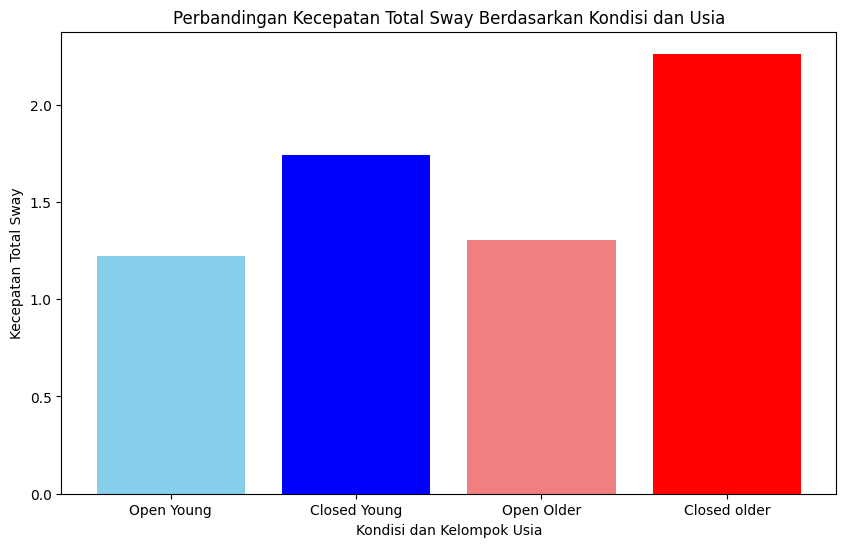

In [11]:

plt.figure(figsize=(10, 6))
plt.bar(conditions_index, total_sway_velocity, color=['skyblue', 'blue', 'lightcoral', 'red']) 
plt.xlabel('Kondisi dan Kelompok Usia')
plt.ylabel('Kecepatan Total Sway')
plt.title('Perbandingan Kecepatan Total Sway Berdasarkan Kondisi dan Usia')
plt.show()


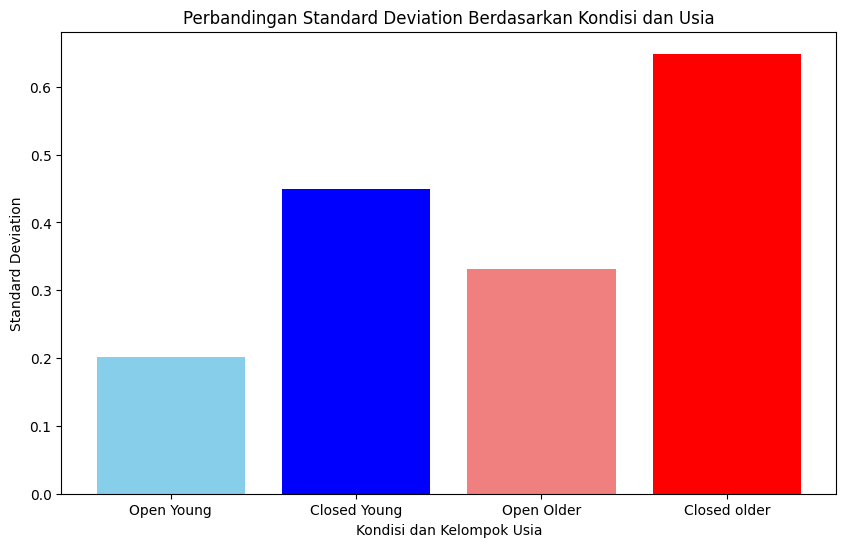

In [12]:

plt.figure(figsize=(10, 6))
plt.bar(conditions_index, COP_std_y, color=['skyblue', 'blue', 'lightcoral', 'red'])
plt.xlabel('Kondisi dan Kelompok Usia')
plt.ylabel('Standard Deviation')
plt.title('Perbandingan Standard Deviation Berdasarkan Kondisi dan Usia')
plt.show()

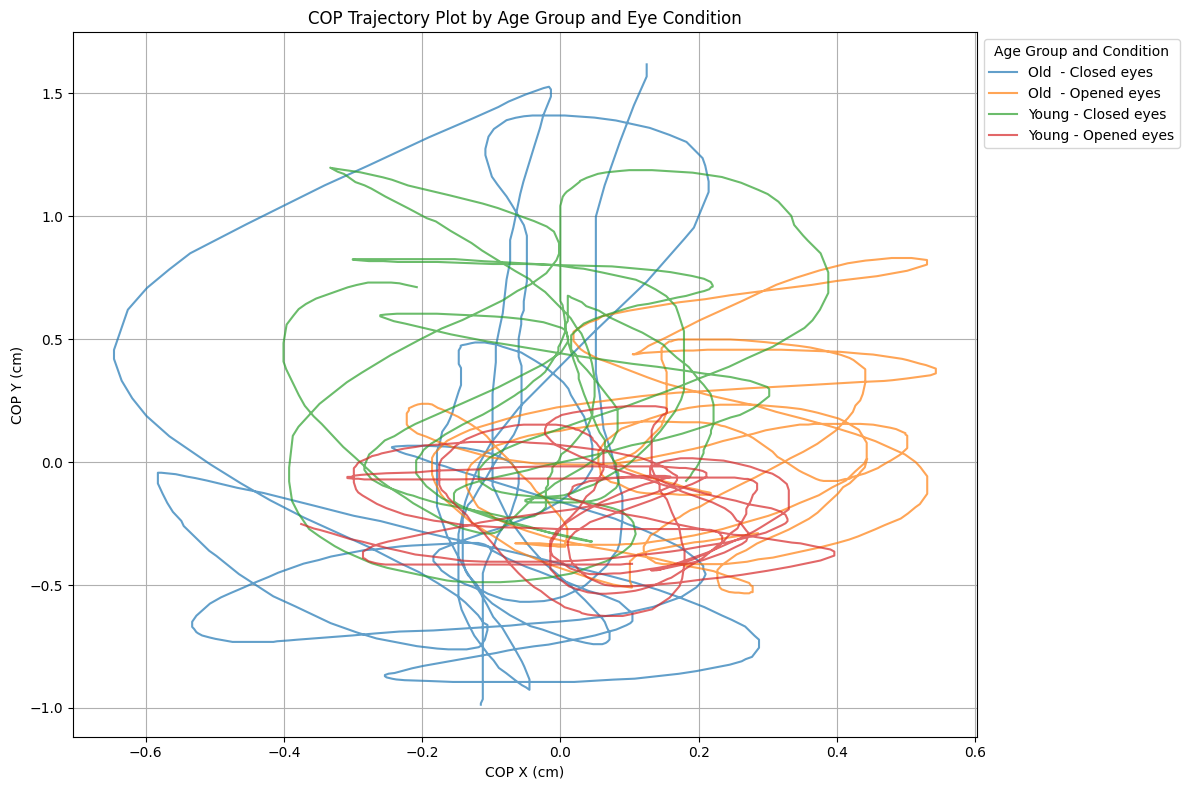

In [14]:
# Preview the dataset to ensure it has the correct columns print(data.head())
# Set up the plot
plt.figure(figsize=(12, 8))
for age_group in age_groups:
    for condition in conditions:
        # Filter the data based on both age group and condition
        condition_age_group_data = data[(data['age_group'] == age_group) 
                                        & (data['condition'] == condition)]
        
        # Plot the COP trajectory (x vs y) for each age group and condition
        plt.plot(condition_age_group_data['COP_x'], 
                 condition_age_group_data['COP_y'], 
                 label=f'{age_group.capitalize()} - {condition.capitalize()} eyes', 
                 alpha=0.7)
        
# Customize the plot
plt.title('COP Trajectory Plot by Age Group and Eye Condition')
plt.xlabel('COP X (cm)')
plt.ylabel('COP Y (cm)')
plt.legend (title='Age Group and Condition', loc='upper left', bbox_to_anchor=(1, 1)) 
plt.grid(True)

# Show the plot 
plt.tight_layout() 